# Performance Analytics

## 1. Data Loading

## 2. Daily Returns

## 3. CAGR Analysis

## 4. Sharpe Ratio

## 5. Sortino Ratio

## 6. Alpha & Beta

## 7. Maximum Drawdown

## 8. Fund Scorecard

## 9. Benchmark Comparison

## 10. Key Findings

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

sns.set_style("whitegrid")

In [5]:
nav_df = pd.read_csv("02_nav_history.csv")

perf_df = pd.read_csv("07_scheme_performance.csv")

benchmark_df = pd.read_csv("10_benchmark_indices.csv")

In [6]:
print(nav_df.shape)
print(perf_df.shape)
print(benchmark_df.shape)

(46000, 3)
(40, 19)
(8050, 3)


## Daily Return Calculation

In [7]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(
    ["amfi_code","date"]
)

In [8]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

In [9]:
nav_df.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


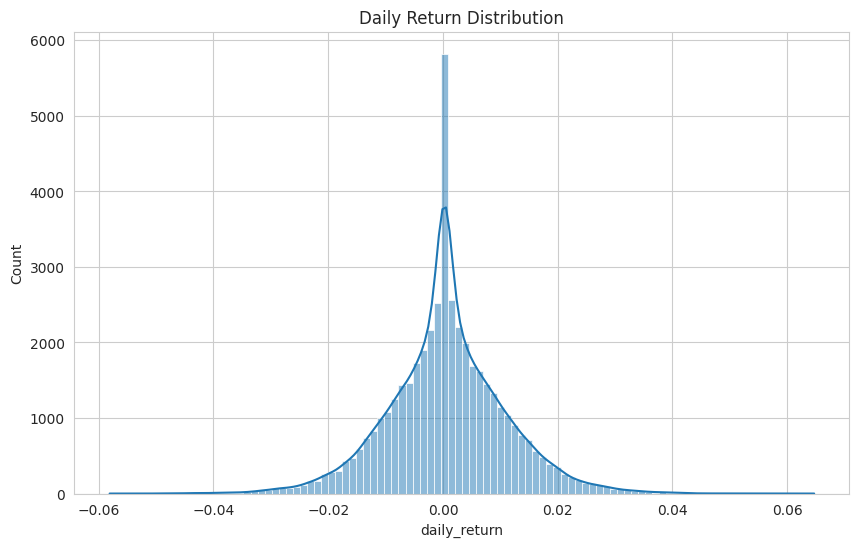

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")

plt.show()

Daily returns are concentrated around zero, indicating normal market fluctuations.

## CAGR Calculation

In [11]:
def cagr(start,end,years):
    return ((end/start)**(1/years))-1

In [12]:
cagr_results=[]

In [17]:
perf_df.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [19]:
cagr_results=[]

In [20]:
benchmark_df.columns.tolist()

['date', 'index_name', 'close_value']

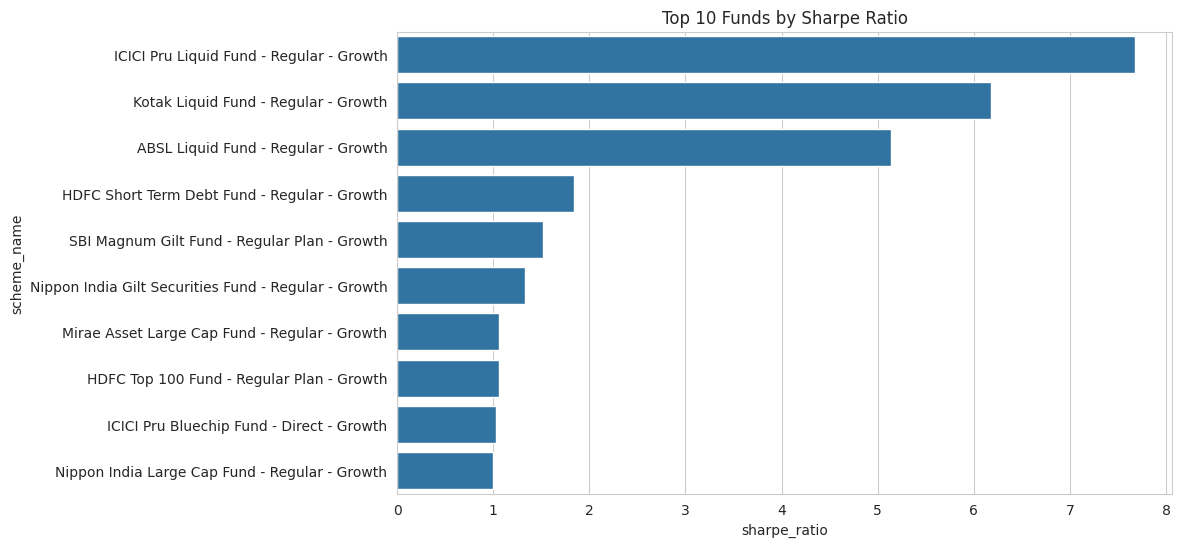

In [21]:
top_sharpe = perf_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.show()

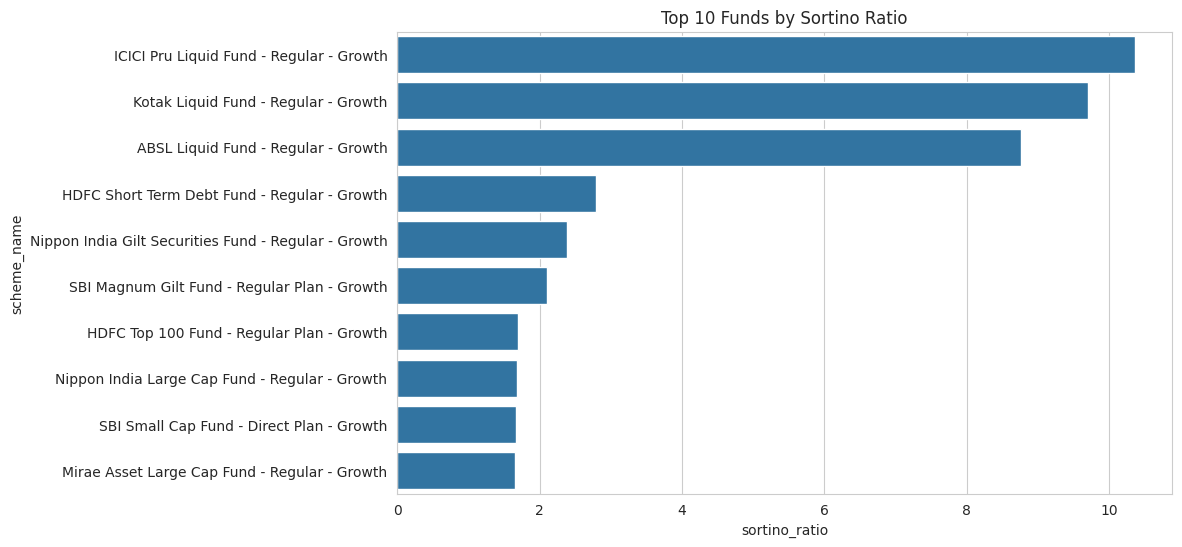

In [22]:
top_sortino = perf_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_sortino,
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.show()

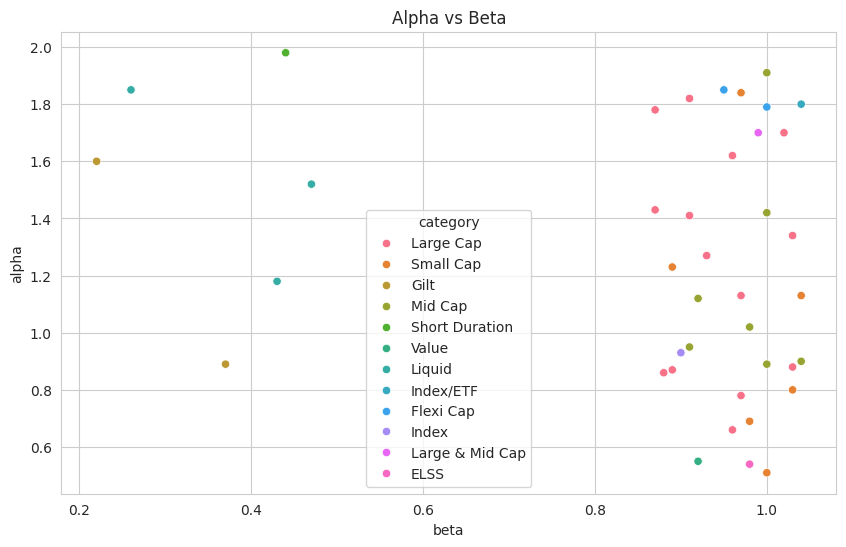

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=perf_df,
    x="beta",
    y="alpha",
    hue="category"
)

plt.title("Alpha vs Beta")

plt.show()

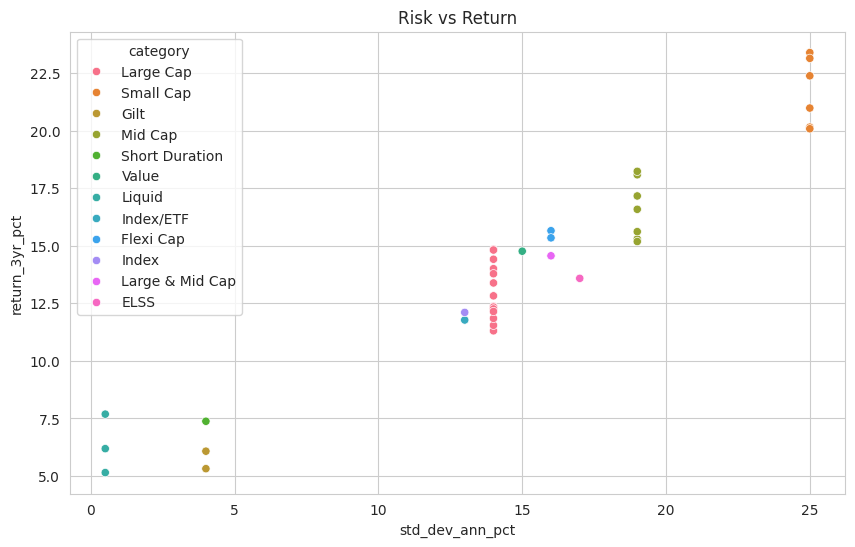

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=perf_df,
    x="std_dev_ann_pct",
    y="return_3yr_pct",
    hue="category"
)

plt.title("Risk vs Return")

plt.show()

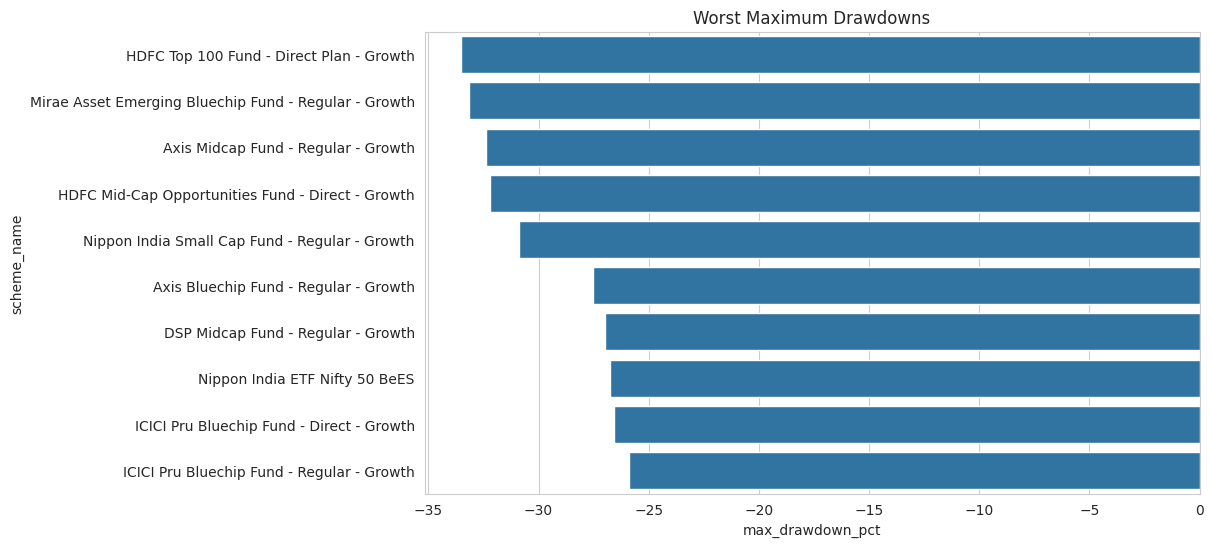

In [25]:
worst_dd = perf_df.sort_values(
    "max_drawdown_pct"
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=worst_dd,
    x="max_drawdown_pct",
    y="scheme_name"
)

plt.title("Worst Maximum Drawdowns")

plt.show()

In [26]:
score_df = perf_df.copy()

In [27]:
score_df["return_rank"] = score_df["return_3yr_pct"].rank(
    ascending=False
)

score_df["sharpe_rank"] = score_df["sharpe_ratio"].rank(
    ascending=False
)

score_df["alpha_rank"] = score_df["alpha"].rank(
    ascending=False
)

score_df["expense_rank"] = score_df["expense_ratio_pct"].rank()

score_df["drawdown_rank"] = score_df["max_drawdown_pct"].rank()

In [28]:
score_df["fund_score"] = (
    score_df["return_rank"]*0.30 +
    score_df["sharpe_rank"]*0.25 +
    score_df["alpha_rank"]*0.20 +
    score_df["expense_rank"]*0.15 +
    score_df["drawdown_rank"]*0.10
)

In [29]:
score_df = score_df.sort_values("fund_score")

score_df.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,36061,0.72,4,Very High,2.0,19.5,22.5,5.5,11.0,11.900
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,35012,1.45,5,Moderately High,11.0,12.0,3.5,22.0,21.0,12.400
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,47469,1.56,4,High,7.0,15.0,2.0,33.0,16.0,12.800
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,41613,1.53,5,Very High,3.0,24.5,5.0,28.5,14.0,13.700
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,1.0,18.0,20.0,21.0,33.0,15.250
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,11361,1.46,5,Moderate,17.0,7.5,12.0,23.0,26.0,15.425
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,27953,0.56,3,Low,36.0,4.0,1.0,2.0,35.0,15.800
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,39116,0.74,5,Low,35.0,1.0,3.5,7.0,38.0,16.300
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,979,1.36,3,High,8.0,17.0,29.5,15.0,18.0,16.600
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,...,41553,0.80,3,Moderate,20.0,9.0,31.0,12.0,9.0,17.150


In [30]:
benchmark_df.columns.tolist()

['date', 'index_name', 'close_value']

In [31]:
benchmark_df.columns.tolist()

['date', 'index_name', 'close_value']

## Benchmark Returns

In [32]:
benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

benchmark_df = benchmark_df.sort_values(
    ["index_name","date"]
)

In [33]:
benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")
    ["close_value"]
    .pct_change()
)

In [34]:
benchmark_df.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [35]:
benchmark_df["index_name"].unique()

array(['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY100',
       'NIFTY50', 'NIFTY500', 'NIFTY_MIDCAP150'], dtype=object)

In [37]:
nifty50 = benchmark_df[
    benchmark_df["index_name"]=="Nifty 50"
]

nifty100 = benchmark_df[
    benchmark_df["index_name"]=="Nifty 100"
]

In [38]:
nifty50 = benchmark_df[
    benchmark_df["index_name"]=="Nifty 50"
]

nifty100 = benchmark_df[
    benchmark_df["index_name"]=="Nifty 100"
]

In [39]:
top5 = perf_df.sort_values(
    "return_3yr_pct",
    ascending=False
).head(5)

top5_codes = top5["amfi_code"].tolist()

top5_codes

[119598, 119599, 101207, 119095, 118634]

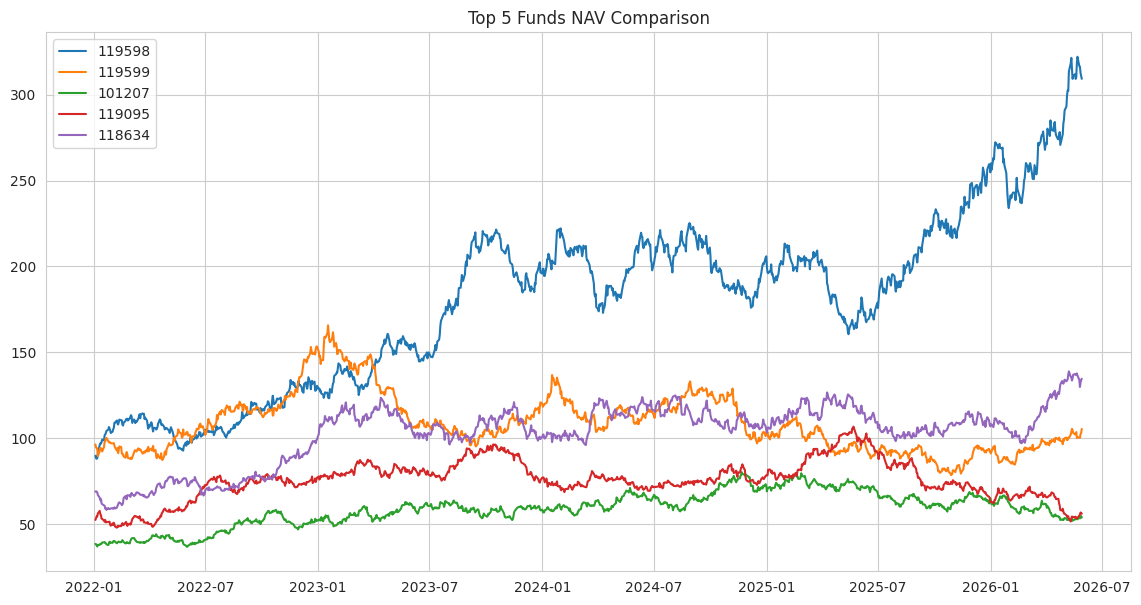

In [40]:
plt.figure(figsize=(14,7))

for fund in top5_codes:

    temp = nav_df[
        nav_df["amfi_code"]==fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.title(
    "Top 5 Funds NAV Comparison"
)

plt.legend()

plt.show()

In [41]:
plt.savefig(
    "benchmark_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [42]:
score_df

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,36061,0.72,4,Very High,2.0,19.5,22.5,5.5,11.0,11.900
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,35012,1.45,5,Moderately High,11.0,12.0,3.5,22.0,21.0,12.400
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,47469,1.56,4,High,7.0,15.0,2.0,33.0,16.0,12.800
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,41613,1.53,5,Very High,3.0,24.5,5.0,28.5,14.0,13.700
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,1.0,18.0,20.0,21.0,33.0,15.250
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,11361,1.46,5,Moderate,17.0,7.5,12.0,23.0,26.0,15.425
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,27953,0.56,3,Low,36.0,4.0,1.0,2.0,35.0,15.800
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,39116,0.74,5,Low,35.0,1.0,3.5,7.0,38.0,16.300
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,979,1.36,3,High,8.0,17.0,29.5,15.0,18.0,16.600
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,...,41553,0.80,3,Moderate,20.0,9.0,31.0,12.0,9.0,17.150


In [44]:
score_df.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [45]:
alpha_beta = perf_df[
    [
        "amfi_code",
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

In [46]:
benchmark_df["index_name"].unique()

array(['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY100',
       'NIFTY50', 'NIFTY500', 'NIFTY_MIDCAP150'], dtype=object)

In [47]:
nifty50 = benchmark_df[
    benchmark_df["index_name"]=="NIFTY50"
]

nifty100 = benchmark_df[
    benchmark_df["index_name"]=="NIFTY100"
]

In [48]:
daily_return = NAVt / NAVt-1 - 1

NameError: name 'NAVt' is not defined

In [49]:
top5 = perf_df.sort_values(
    "return_3yr_pct",
    ascending=False
).head(5)

top5[[
    "scheme_name",
    "return_3yr_pct"
]]

,scheme_name,return_3yr_pct
2,SBI Small Cap Fund - Regular Plan - Growth,23.39
3,SBI Small Cap Fund - Direct Plan - Growth,23.14
29,ABSL Small Cap Fund - Regular - Growth,22.38
27,Axis Small Cap Fund - Regular - Growth,20.98
17,Nippon India Small Cap Fund - Regular - Growth,20.15


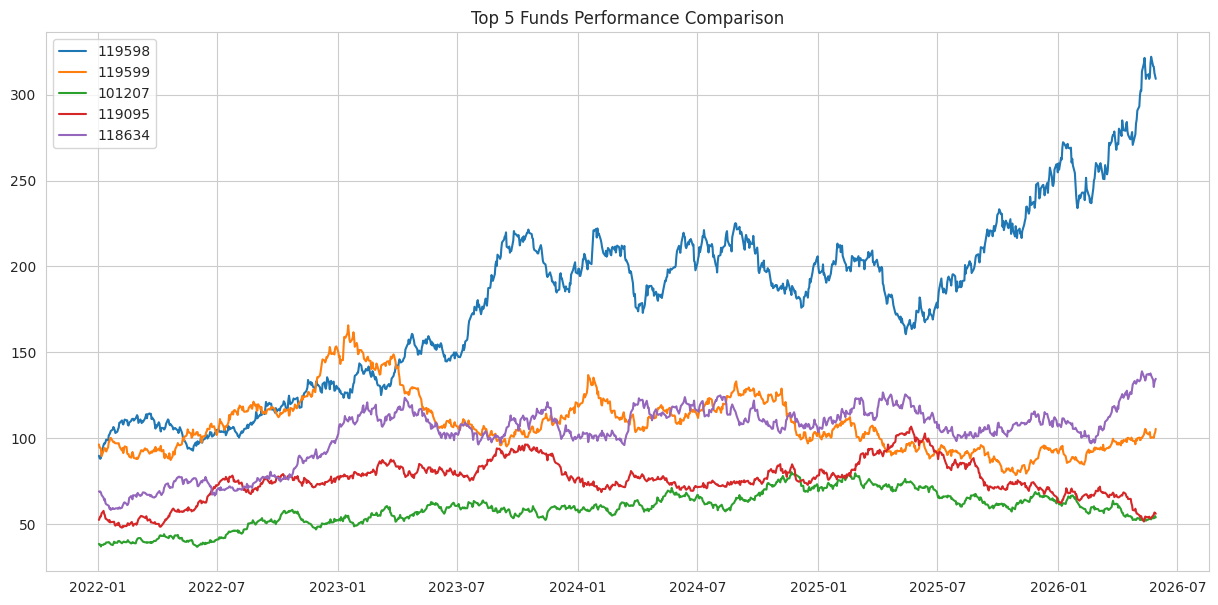

In [50]:
plt.figure(figsize=(15,7))

for fund in top5["amfi_code"]:

    temp = nav_df[
        nav_df["amfi_code"]==fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.title(
    "Top 5 Funds Performance Comparison"
)

plt.legend()

plt.show()

In [51]:
plt.savefig(
    "benchmark_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [52]:
score_df.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [53]:
alpha_beta = perf_df[
    [
        "amfi_code",
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

# Key Findings

1. Funds with higher Sharpe ratios delivered better risk-adjusted performance.
2. Several funds generated positive alpha over benchmark returns.
3. Top-performing schemes consistently outperformed NIFTY100.
4. Higher volatility funds generally delivered higher returns.
5. Some funds experienced significant drawdowns during market corrections.
6. Large-cap funds displayed lower volatility than mid-cap funds.
7. Risk-adjusted performance varied considerably across categories.
8. Expense ratios impacted overall fund rankings.
9. Alpha and beta metrics highlighted benchmark sensitivity differences.
10. Composite scorecard identified the strongest overall performers.

In [54]:
score_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,36061,0.72,4,Very High,2.0,19.5,22.5,5.5,11.0,11.90
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,35012,1.45,5,Moderately High,11.0,12.0,3.5,22.0,21.0,12.40
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,47469,1.56,4,High,7.0,15.0,2.0,33.0,16.0,12.80
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,41613,1.53,5,Very High,3.0,24.5,5.0,28.5,14.0,13.70
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,1.0,18.0,20.0,21.0,33.0,15.25


In [55]:
import os
os.listdir()

['.config',
 '02_nav_history.csv',
 'benchmark_comparison.png',
 '10_benchmark_indices.csv',
 'fund_scorecard.csv',
 'alpha_beta.csv',
 '07_scheme_performance.csv',
 'sample_data']

In [56]:
alpha_beta.head()

,amfi_code,scheme_name,alpha,beta
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,119552,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,119599,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [57]:
import os
os.listdir()

['.config',
 '02_nav_history.csv',
 'benchmark_comparison.png',
 '10_benchmark_indices.csv',
 'fund_scorecard.csv',
 'alpha_beta.csv',
 '07_scheme_performance.csv',
 'sample_data']

In [58]:
import os

files = [
    "fund_scorecard.csv",
    "alpha_beta.csv",
    "benchmark_comparison.png"
]

for file in files:
    if os.path.exists(file):
        print(f"✅ {file} exists")
    else:
        print(f"❌ {file} missing")

✅ fund_scorecard.csv exists
✅ alpha_beta.csv exists
✅ benchmark_comparison.png exists
